Loading images...
Preprocessing images...
Loading cell boundary data...
Creating polygons...
Rasterizing polygons to label mask...
Unique values in rasterized mask: [    0     1     2 ... 47424 47425 47426]
Computing mean intensity per cell...
Mean intensity per cell saved to: 983_ICG/983_mean_intensity_per_cell.csv
Rendering polygon overlay on image for validation...


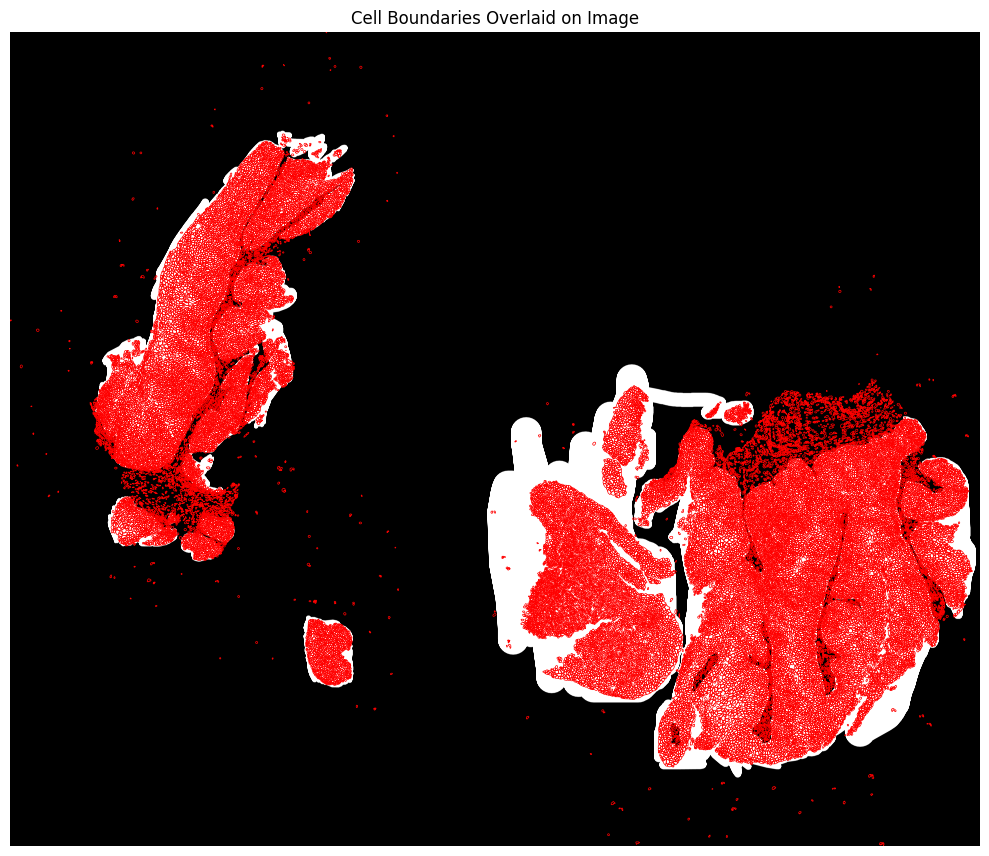

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from imageio.v2 import imread
from shapely.geometry import Polygon
from rasterio.features import rasterize
from affine import Affine
import matplotlib.pyplot as plt

#====================================================================================================
# Set parameters
#====================================================================================================

# Set working directory
os.chdir("Z:/WillHartnett/Xenium UPC")

# Parameters
workflow_parameters = {
    'sample': '983',
    'pixel_size': 0.2125
}

#====================================================================================================
# Load and process images
#====================================================================================================

print('Loading images...')
img = np.asarray(imread(f'{workflow_parameters['sample']}_ICG/mask.tif').astype(np.float32))

print('Preprocessing images...')
height, width = img.shape

#====================================================================================================
# Load and prepare cell boundaries
#====================================================================================================

print('Loading cell boundary data...')
boundary_data = pd.read_csv(f'{workflow_parameters['sample']}_ICG/{workflow_parameters['sample']}_cell_boundaries.csv')

# Convert microns to pixels
boundary_data["vertex_x"] = boundary_data["vertex_x"] / workflow_parameters['pixel_size']
boundary_data["vertex_y"] = boundary_data["vertex_y"] / workflow_parameters['pixel_size']

# Flip Y-axis if needed (optional)
# boundary_data["vertex_y"] = height - boundary_data["vertex_y"]

# Create valid polygons, close ring if needed
def make_valid_polygon(df):
    coords = list(zip(df["vertex_x"], df["vertex_y"]))
    if coords[0] != coords[-1]:
        coords.append(coords[0])  # Ensure polygon is closed
    poly = Polygon(coords)
    return poly.buffer(0)  # Buffer(0) to clean geometry if needed

print('Creating polygons...')
boundary_polygons = (
    boundary_data.groupby("cell_id", group_keys=False)
    .apply(make_valid_polygon, include_groups=False)
    .reset_index()
    .rename(columns={0: "geometry"})
)
boundary_gdf = gpd.GeoDataFrame(boundary_polygons, geometry="geometry")

# Assign integer labels to each cell for rasterization
boundary_gdf["label"] = range(1, len(boundary_gdf) + 1)
label_to_cell_id = dict(zip(boundary_gdf["label"], boundary_gdf["cell_id"]))

#====================================================================================================
# Rasterization
#====================================================================================================
print('Rasterizing polygons to label mask...')
transform = Affine.translation(0, height) * Affine.scale(1, -1)  # coordinates in pixel space

cell_mask = rasterize(
    [(geom, label) for geom, label in zip(boundary_gdf.geometry, boundary_gdf.label)],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype=np.int32
)

unique_ids = np.unique(cell_mask)
print("Unique values in rasterized mask:", unique_ids)

#====================================================================================================
# Compute mean intensity per cell
#====================================================================================================
print('Computing mean intensity per cell...')
cell_mask_flipped = np.flipud(cell_mask)
valid_pixels = cell_mask_flipped > 0
cell_ids = cell_mask_flipped[valid_pixels]
pixel_values = img[valid_pixels]

mean_df = pd.DataFrame({"label": cell_ids, "intensity": pixel_values})
mean_intensities_df = mean_df.groupby("label").mean().reset_index()
mean_intensities_df.rename(columns={"intensity": "mean_intensity"}, inplace=True)

# Map integer labels back to original cell_id
mean_intensities_df["cell_id"] = mean_intensities_df["label"].map(label_to_cell_id)
mean_intensities_df = mean_intensities_df[["cell_id", "mean_intensity"]]

#====================================================================================================
# Save results
#====================================================================================================
output_path = f"{workflow_parameters['sample']}_ICG/{workflow_parameters['sample']}_mean_intensity_per_cell.csv"
mean_intensities_df.to_csv(output_path, index=False)
print(f'Mean intensity per cell saved to: {output_path}')

#====================================================================================================
# Validate overlay (optional)
#====================================================================================================
print("Rendering polygon overlay on image for validation...")
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img, cmap='gray')
boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.5)
plt.title("Cell Boundaries Overlaid on Image")
plt.axis("off")
plt.tight_layout()
plt.show()

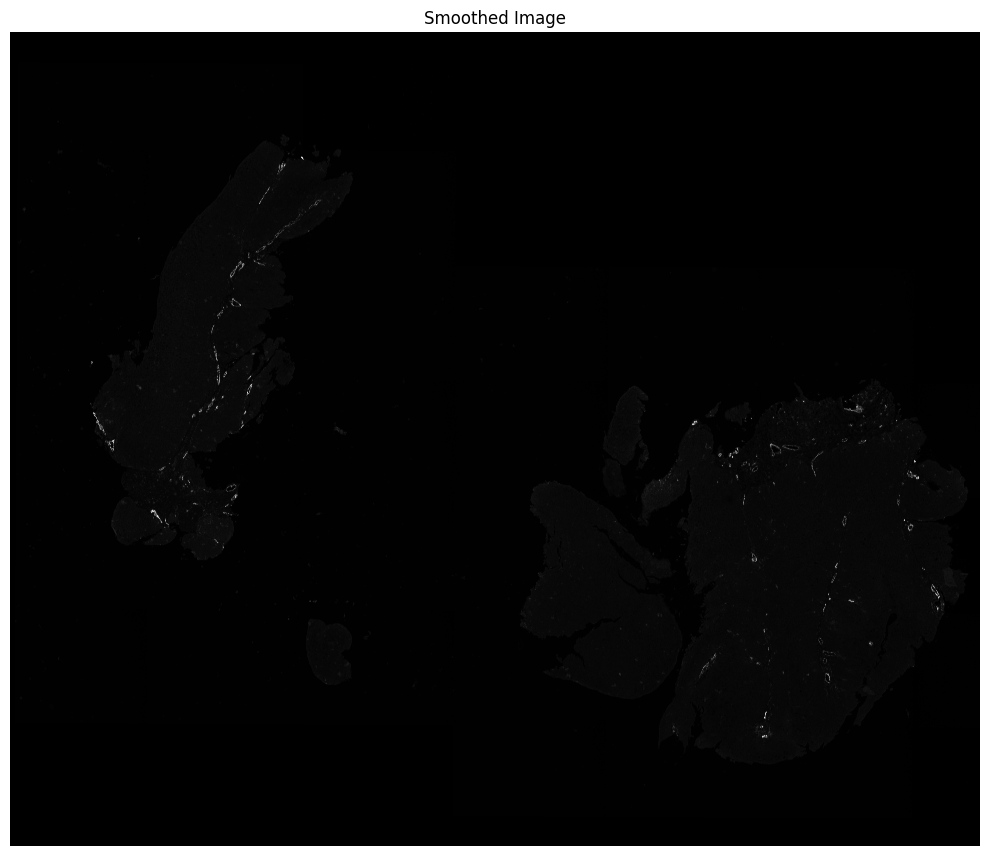

In [2]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img, cmap='gray')
plt.title("Smoothed Image")
plt.axis("off")
plt.tight_layout()
plt.show()